# Gradient Boosting — XGBoost & LightGBM

End-to-end classification project: load a banking dataset, preprocess it, train XGBoost and LightGBM, compare their performance, tune the models, and understand feature importance.


## Project Workflow

1. Load and understand the dataset
2. Clean and prepare the data
3. Split into training and testing sets
4. Build XGBoost and LightGBM models
5. Evaluate using Accuracy, Precision, Recall, F1 and ROC-AUC
6. Compare both models
7. Tune the models using cross-validation
8. Plot feature importance
9. Make a prediction on a new customer


In [ ]:
!pip install -q xgboost lightgbm

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')


## 1. Load the Dataset

Download the banking dataset later and upload it to Colab. Change the file name below if needed.


In [ ]:
file_path = '/content/banking_loan_default_dataset_500_rows.csv'
df = pd.read_csv(file_path)

df.head()


,customer_id,age,income_monthly,loan_amount,credit_score,employment_years,debt_to_income,existing_loans,dependents,bank_balance,interest_rate,employment_status,marital_status,education,loan_purpose,city_tier,previous_defaults,loan_default
0,CUST1362,29,143036.0,200322,574.0,4.7,0.22,5,4,301629,13.12,Business,Married,Graduate,Home,Tier 3,0,No
1,CUST1074,28,56102.0,863738,810.0,2.8,0.13,5,3,620324,8.92,Salaried,Married,Undergraduate,Home,Tier 2,0,Yes
2,CUST1375,40,93703.0,428165,687.0,8.3,0.51,3,2,94037,10.44,Business,Divorced,Undergraduate,Education,Tier 3,0,Yes
3,CUST1156,52,123787.0,364997,651.0,0.6,0.17,0,0,483454,8.08,Self-employed,Married,Postgraduate,Education,Tier 3,1,Yes
4,CUST1105,25,48355.0,855688,662.0,3.6,0.47,3,0,906311,8.91,Salaried,Married,Undergraduate,Education,Tier 1,0,Yes


In [ ]:
df.shape

(500, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        500 non-null    object 
 1   age                500 non-null    int64  
 2   income_monthly     485 non-null    float64
 3   loan_amount        500 non-null    int64  
 4   credit_score       485 non-null    float64
 5   employment_years   485 non-null    float64
 6   debt_to_income     485 non-null    float64
 7   existing_loans     500 non-null    int64  
 8   dependents         500 non-null    int64  
 9   bank_balance       500 non-null    int64  
 10  interest_rate      500 non-null    float64
 11  employment_status  500 non-null    object 
 12  marital_status     500 non-null    object 
 13  education          485 non-null    object 
 14  loan_purpose       500 non-null    object 
 15  city_tier          500 non-null    object 
 16  previous_defaults  500 non

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(15)

,0
credit_score,15
income_monthly,15
education,15
debt_to_income,15
employment_years,15
customer_id,0
age,0
loan_amount,0
dependents,0
existing_loans,0


## 2. Set the Target Column

Change `target_column` to the column that tells us whether the customer defaulted.


In [ ]:
target_column = 'loan_default'

df = df.dropna(subset=[target_column]).copy()

X = df.drop(columns=[target_column])
y = df[target_column]

print('Target values:')
print(y.value_counts())


Target values:
loan_default
Yes    357
No     143
Name: count, dtype: int64


## 3. Prepare the Target

The models need the target in numeric form. If the target is already numeric, this cell still safely converts the target classes into 0 and 1.


In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y.astype(str))

print('Classes:', list(label_encoder.classes_))
print('Encoded classes:', np.unique(y))


Classes: ['No', 'Yes']
Encoded classes: [0 1]


In [ ]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print('Numeric features:', numeric_features)
print('\nCategorical features:', categorical_features)


Numeric features: ['age', 'income_monthly', 'loan_amount', 'credit_score', 'employment_years', 'debt_to_income', 'existing_loans', 'dependents', 'bank_balance', 'interest_rate', 'previous_defaults']

Categorical features: ['customer_id', 'employment_status', 'marital_status', 'education', 'loan_purpose', 'city_tier']


## 4. Train-Test Split

We keep 20% of the data completely separate for final testing.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)


Training data: (400, 17)
Testing data: (100, 17)


## 5. Preprocessing

Tree-based boosting models do not require feature scaling. We only handle missing values and convert categorical columns using one-hot encoding.


In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## 6. Build XGBoost Model

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

xgb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'income_monthly',
                                                   'loan_amount',
                                                   'credit_score',
                                                   'employment_years',
                                                   'debt_to_income',
                                                   'existing_loans',
                                                   'dependents', 'bank_balance',
                                                   'interest_rate',
                                                   'previous_defaults']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImpu...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

## 7. Build LightGBM Model

In [ ]:
lgb_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)

lgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb_model)
])

lgb_pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'income_monthly',
                                                   'loan_amount',
                                                   'credit_score',
                                                   'employment_years',
                                                   'debt_to_income',
                                                   'existing_loans',
                                                   'dependents', 'bank_balance',
                                                   'interest_rate',
                                                   'previous_defaults']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customer_id',
                                                   'employment_status',
                                                   'marital_status',
                                                   'education', 'loan_purpose',
                                                   'city_tier'])])),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                n_estimators=200, random_state=42,
                                subsample=0.8, verbosity=-1))])

## 8. Evaluate Both Models

In [ ]:
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

lgb_pred = lgb_pipeline.predict(X_test)
lgb_prob = lgb_pipeline.predict_proba(X_test)[:, 1]

def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

results = pd.DataFrame([
    get_metrics(y_test, xgb_pred, xgb_prob),
    get_metrics(y_test, lgb_pred, lgb_prob)
], index=['XGBoost', 'LightGBM'])

results.round(4)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.71,0.7500,0.8873,0.8129,0.7125
LightGBM,0.69,0.7439,0.8592,0.7974,0.7067


In [ ]:
print('XGBoost Classification Report')
print(classification_report(y_test, xgb_pred, target_names=label_encoder.classes_, zero_division=0))

print('LightGBM Classification Report')
print(classification_report(y_test, lgb_pred, target_names=label_encoder.classes_, zero_division=0))


XGBoost Classification Report
              precision    recall  f1-score   support

          No       0.50      0.28      0.36        29
         Yes       0.75      0.89      0.81        71

    accuracy                           0.71       100
   macro avg       0.62      0.58      0.58       100
weighted avg       0.68      0.71      0.68       100

LightGBM Classification Report
              precision    recall  f1-score   support

          No       0.44      0.28      0.34        29
         Yes       0.74      0.86      0.80        71

    accuracy                           0.69       100
   macro avg       0.59      0.57      0.57       100
weighted avg       0.66      0.69      0.66       100



## 9. Compare Confusion Matrices

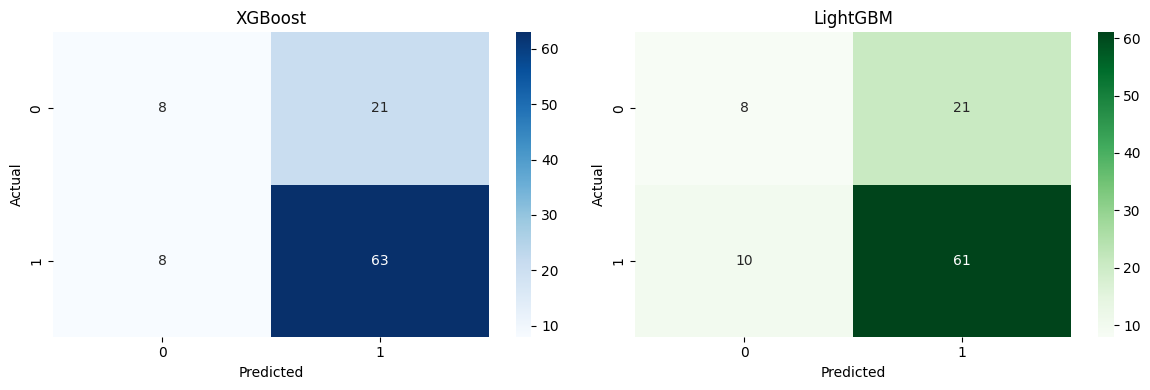

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('XGBoost')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, lgb_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('LightGBM')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


## 10. ROC Curve

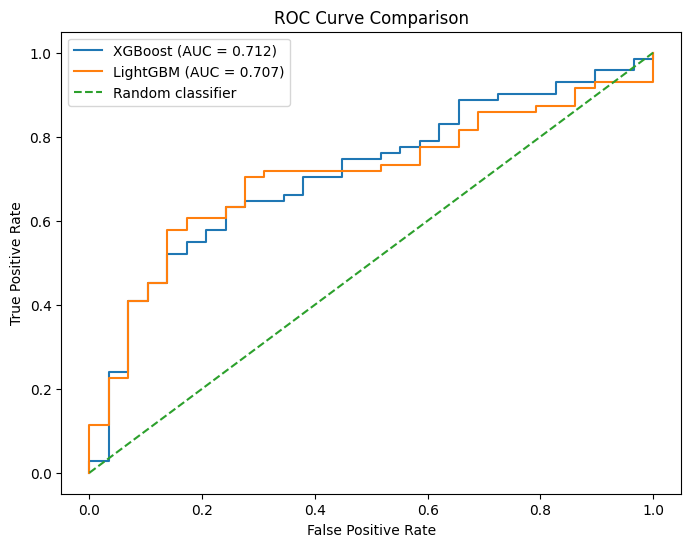

In [ ]:
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_prob)

plt.figure(figsize=(8, 6))
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})')
plt.plot(lgb_fpr, lgb_tpr, label=f'LightGBM (AUC = {roc_auc_score(y_test, lgb_prob):.3f})')
plt.plot([0, 1], [0, 1], '--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()


## 11. Feature Importance — XGBoost

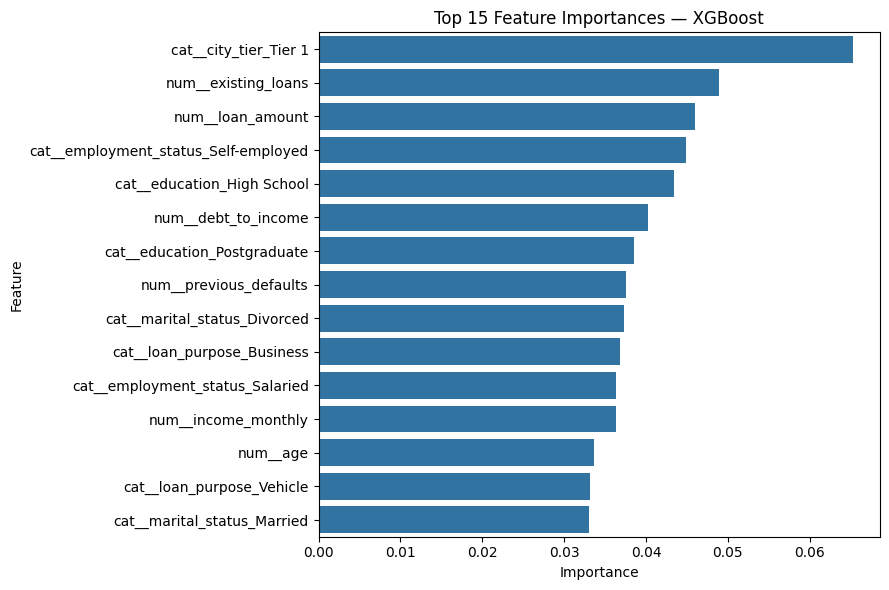

In [ ]:
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
xgb_importance = xgb_pipeline.named_steps['model'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=xgb_importance_df, x='Importance', y='Feature')
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()


## 12. Feature Importance — LightGBM

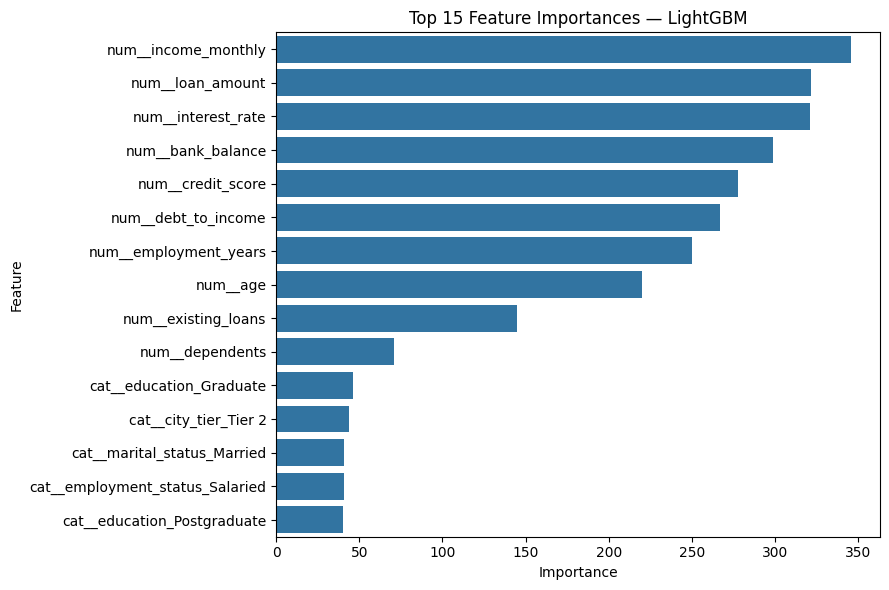

In [ ]:
feature_names_lgb = lgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
lgb_importance = lgb_pipeline.named_steps['model'].feature_importances_

lgb_importance_df = pd.DataFrame({
    'Feature': feature_names_lgb,
    'Importance': lgb_importance
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=lgb_importance_df, x='Importance', y='Feature')
plt.title('Top 15 Feature Importances — LightGBM')
plt.tight_layout()
plt.show()


## 13. Hyperparameter Tuning — XGBoost

We keep the search small so it remains practical in Colab.


In [ ]:
xgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.05, 0.1]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print('Best parameters:', xgb_grid.best_params_)
print('Best CV F1:', round(xgb_grid.best_score_, 4))


Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}
Best CV F1: 0.8128


## 14. Hyperparameter Tuning — LightGBM

In [ ]:
lgb_param_grid = {
    'model__n_estimators': [100, 200],
    'model__num_leaves': [15, 31],
    'model__learning_rate': [0.05, 0.1]
}

lgb_grid = GridSearchCV(
    lgb_pipeline,
    lgb_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

lgb_grid.fit(X_train, y_train)

print('Best parameters:', lgb_grid.best_params_)
print('Best CV F1:', round(lgb_grid.best_score_, 4))


Best parameters: {'model__learning_rate': 0.05, 'model__n_estimators': 100, 'model__num_leaves': 15}
Best CV F1: 0.8058


## 15. Evaluate the Tuned Models

In [ ]:
xgb_tuned_pred = xgb_grid.predict(X_test)
xgb_tuned_prob = xgb_grid.predict_proba(X_test)[:, 1]

lgb_tuned_pred = lgb_grid.predict(X_test)
lgb_tuned_prob = lgb_grid.predict_proba(X_test)[:, 1]

tuned_results = pd.DataFrame([
    get_metrics(y_test, xgb_tuned_pred, xgb_tuned_prob),
    get_metrics(y_test, lgb_tuned_pred, lgb_tuned_prob)
], index=['Tuned XGBoost', 'Tuned LightGBM'])

tuned_results.round(4)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Tuned XGBoost,0.72,0.7590,0.8873,0.8182,0.7115
Tuned LightGBM,0.67,0.7317,0.8451,0.7843,0.6809


## 16. Final Model Comparison

Use F1 and ROC-AUC along with accuracy. The final choice should also consider the business meaning of false positives and false negatives.


In [ ]:
all_results = pd.concat([results, tuned_results])
all_results.round(4)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
XGBoost,0.71,0.7500,0.8873,0.8129,0.7125
LightGBM,0.69,0.7439,0.8592,0.7974,0.7067
Tuned XGBoost,0.72,0.7590,0.8873,0.8182,0.7115
Tuned LightGBM,0.67,0.7317,0.8451,0.7843,0.6809


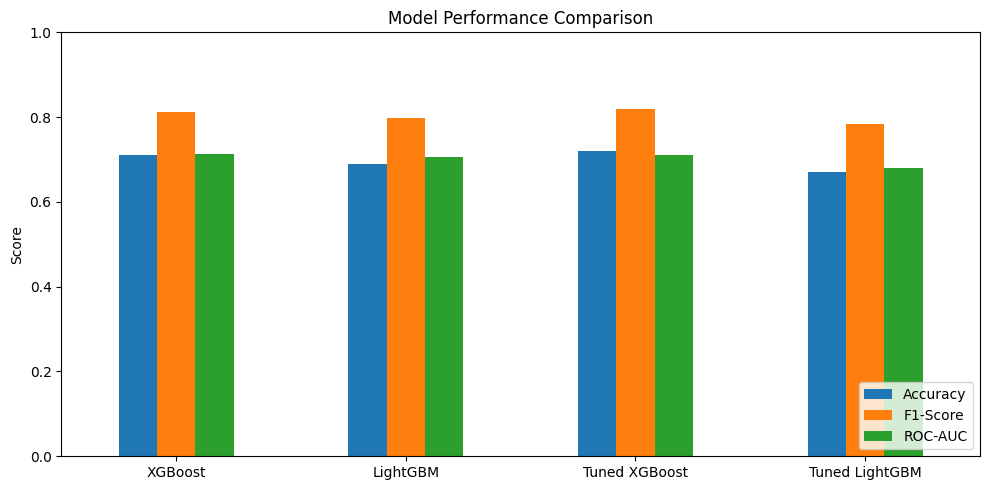

In [ ]:
all_results[['Accuracy', 'F1-Score', 'ROC-AUC']].plot(kind='bar', figsize=(10, 5))
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 17. Make a Prediction for a New Customer

The example below copies one test row so the notebook runs without guessing the dataset's column names. Later, replace it with actual customer values.


In [ ]:
new_customer = X_test.iloc[[0]].copy()

prediction = xgb_grid.predict(new_customer)[0]
probability = xgb_grid.predict_proba(new_customer)[0, 1]

print('Predicted class:', label_encoder.inverse_transform([prediction])[0])
print('Probability of class 1:', round(probability, 4))

print('\nInput customer:')
display(new_customer)


Predicted class: Yes
Probability of class 1: 0.895

Input customer:


,customer_id,age,income_monthly,loan_amount,credit_score,employment_years,debt_to_income,existing_loans,dependents,bank_balance,interest_rate,employment_status,marital_status,education,loan_purpose,city_tier,previous_defaults
152,CUST1046,29,57954.0,282050,723.0,NaN,0.27,5,0,270471,8.41,Self-employed,Married,Postgraduate,Vehicle,Tier 2,0


## Final Takeaways

- XGBoost and LightGBM are gradient boosting algorithms based on decision trees.
- They build trees sequentially, with later trees improving the previous model.
- Accuracy alone may not be enough for an imbalanced banking problem.
- F1 balances precision and recall, while ROC-AUC measures ranking performance across thresholds.
- Cross-validation helps select hyperparameters more reliably.
- Feature importance helps us understand which input variables contributed most to the model.
